In [1]:
import json
import pandas as pd
import numpy as np

data_path = '../preprocess/ALC_features_Functional_toy.json'

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
df = pd.read_json(data_path, orient='index')
df.head()

,intoxicated,breath alcohol concentration,blood alcohol concentration,features
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses2069/0732069050_h_00.wav,na,0.00000,0.00000,{'F0semitoneFrom27.5Hz_sma3nz_amean': [24.8224...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses3045/5433045004_h_00.wav,a,0.00047,0.00047,{'F0semitoneFrom27.5Hz_sma3nz_amean': [33.2336...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses1097/0961097007_h_00.wav,a,0.00064,0.00068,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.1055...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses1006/0061006026_h_00.wav,a,0.00081,0.00073,{'F0semitoneFrom27.5Hz_sma3nz_amean': [33.9375...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4066/5864066025_h_00.wav,na,0.00000,0.00000,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.2502...


In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2)

In [38]:
train['features'][0]

{'F0semitoneFrom27.5Hz_sma3nz_amean': [31.300291061401367],
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm': [0.192315474152565],
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': [31.18489646911621],
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': [32.27739334106445],
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0': [35.89854431152344],
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2': [4.713647842407227],
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope': [292.80560302734375],
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope': [174.69168090820312],
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope': [126.653076171875],
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope': [110.34541320800781],
 'loudness_sma3_amean': [0.142181813716888],
 'loudness_sma3_stddevNorm': [0.7129378318786621],
 'loudness_sma3_percentile20.0': [0.039571605622768],
 'loudness_sma3_percentile50.0': [0.12557521462440402],
 'loudness_sma3_percentile80.0': [0.200888752937316],
 'loudness_sma3_pctlrange0-2': [0.161317139863967],
 'loudness

# Majority Baseline 
(Just one dummy feature)

In [39]:
# this keeps one first feature -- should not be informative enough for the model to work
def features_to_vec(feature_dict):
#     out_vector = []
#     for feature in feature_dict.values():
#         out_vector.append(feature)
    return [0]

In [40]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[5])} dimensions.")

The dataset has 121 data samples.
Each data sample is a vector of 1 dimensions.


In [41]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [42]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [43]:
X_train[2:4]
#look at this; maybe we could collapse redundant features? like do PCA or any other dimensionality reduction

[[0], [0]]

In [44]:
y_train[:2]

[0, 0]

In [45]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [46]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

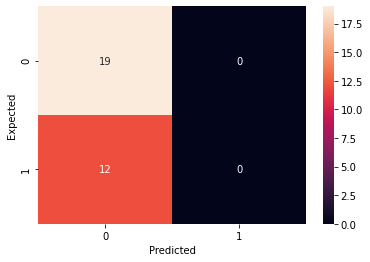

In [47]:
evaluate_classifier(nb_classifier, X_test, y_test)

# Actual Baseline

In [20]:
# this simply flattens all the features into one long concatenated vector
def features_to_vec(feature_dict):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

features_to_vec(train['features'][0])

[31.300291061401367,
 0.192315474152565,
 31.18489646911621,
 32.27739334106445,
 35.89854431152344,
 4.713647842407227,
 292.80560302734375,
 174.69168090820312,
 126.653076171875,
 110.34541320800781,
 0.142181813716888,
 0.7129378318786621,
 0.039571605622768,
 0.12557521462440402,
 0.200888752937316,
 0.161317139863967,
 2.385072469711303,
 1.941859364509582,
 2.109143495559692,
 1.53588056564331,
 0.043279513716697006,
 1.06681215763092,
 19.83521270751953,
 0.7832460403442381,
 13.678300857543945,
 0.762899756431579,
 15.239831924438477,
 0.7977772951126091,
 5.4776763916015625,
 1.71841561794281,
 0.028489261865615,
 1.9638779163360591,
 1.090027093887329,
 1.099354743957519,
 7.69279146194458,
 0.706468045711517,
 6.094527244567871,
 2.593774795532226,
 25.34231948852539,
 0.48727720975875805,
 565.1573486328125,
 0.278666973114013,
 1331.7637939453125,
 0.162698090076446,
 -116.7205810546875,
 -0.7589344978332521,
 1676.7054443359375,
 0.13707338273525202,
 959.1298217773438,


In [23]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[7])} dimensions.")

The dataset has 121 data samples.
Each data sample is a vector of 88 dimensions.


In [24]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [25]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [26]:
#([set([type(x) for x in y]) for y in X_train])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [27]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

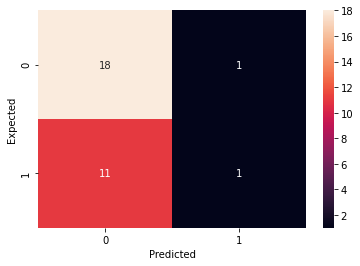

In [28]:
evaluate_classifier(nb_classifier, X_test, y_test)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [32]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
accuracy = knn_classifier.score(X_test, y_test)
accuracy

0.5806451612903226

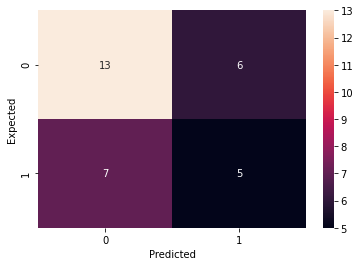

In [33]:
evaluate_classifier(knn_classifier, X_test, y_test)

In [34]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
accuracy = rf_classifier.score(X_test, y_test)
accuracy 

0.6129032258064516

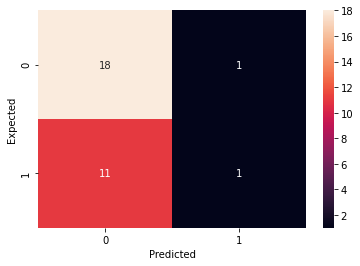

In [35]:
evaluate_classifier(rf_classifier, X_test, y_test)

In [36]:
svm_classifier = svm.LinearSVC()
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

/usr/lib64/python3.10/site-packages/sklearn/svm/_base.py:1199: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.6129032258064516

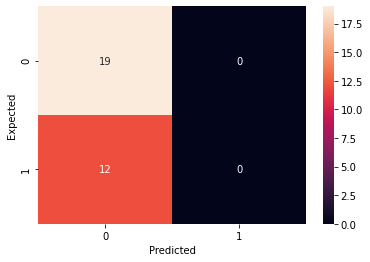

In [37]:
evaluate_classifier(svm_classifier, X_test, y_test)